In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
anime=pd.read_csv('anime.csv')
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [3]:
anime.shape

(12294, 7)

In [4]:
anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [5]:
anime.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [6]:
anime.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [7]:
anime.nunique()


anime_id    12294
name        12292
genre        3264
type            6
episodes      187
rating        598
members      6706
dtype: int64

In [8]:
anime['type'].unique()

array(['Movie', 'TV', 'OVA', 'Special', 'Music', 'ONA', nan], dtype=object)

In [9]:
anime['rating'].min()

1.67

In [10]:
anime['rating'].max()

10.0

In [11]:
anime['genre'].value_counts()

genre
Hentai                                                  823
Comedy                                                  523
Music                                                   301
Kids                                                    199
Comedy, Slice of Life                                   179
                                                       ... 
Hentai, Parody, Sci-Fi                                    1
Hentai, Historical, Mystery                               1
Action, Comedy, Hentai                                    1
Comedy, Ecchi, Fantasy, Parody, Yuri                      1
Action, Mecha, Military, School, Sci-Fi, Super Power      1
Name: count, Length: 3264, dtype: int64

In [12]:
anime['type'].value_counts()

type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: count, dtype: int64

<Axes: xlabel='type', ylabel='count'>

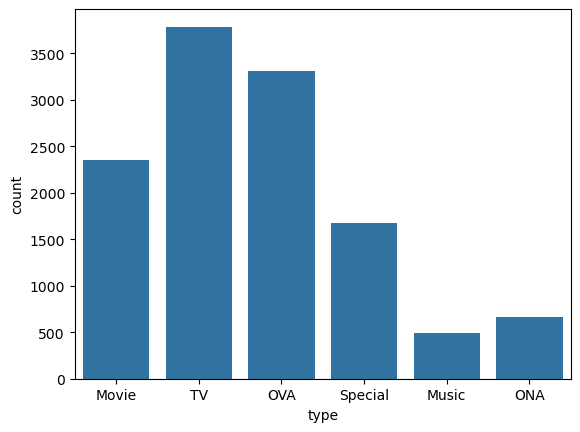

In [13]:
sns.countplot(data=anime,x='type')

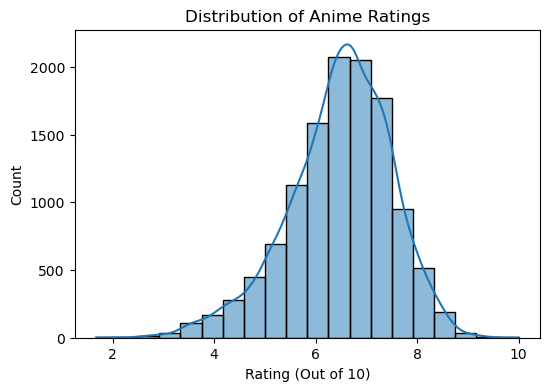

In [14]:
'''plt.figure(figsize=(6,4))
sns.histplot(data=anime,x='rating',bins=10,kde=True)
plt.title('distribution of rating')
plt.show()'''


plt.figure(figsize=(6, 4))
sns.histplot(anime["rating"], bins=20, kde=True)
plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating (Out of 10)")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='rating', ylabel='Count'>

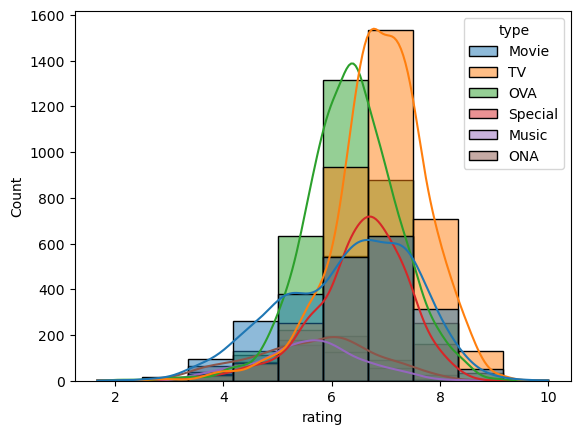

In [15]:
sns.histplot(data=anime,x='rating',bins=10,kde=True,hue='type')

In [16]:
'''grp=anime.groupby('type')
grp.agg('mean') 

_IncompleteInputError: incomplete input (2309191394.py, line 1)

In [17]:
t=anime[anime['type']='TV'][['type']]

SyntaxError: cannot assign to subscript here. Maybe you meant '==' instead of '='? (2411529257.py, line 1)

In [18]:
rating_df[rating_df['rating'] == -1][['user_id', 'anime_id']]

NameError: name 'rating_df' is not defined

<Axes: >

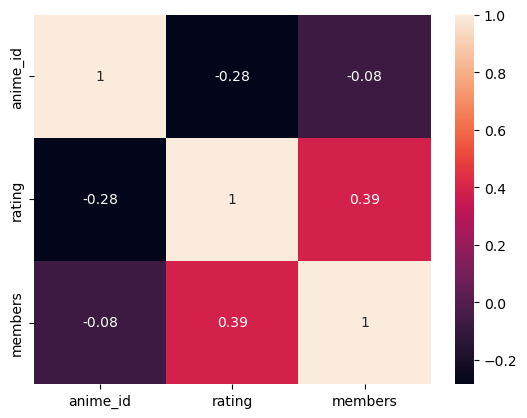

In [19]:
sns.heatmap(anime.select_dtypes(include=['float64', 'int64']).corr(),annot=True)

In [20]:
anime.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [21]:
genre_mode=anime['genre'].mode()[0]
genre_mode

'Hentai'

In [22]:
anime1=anime.copy()

In [23]:
anime1['genre']=anime1['genre'].fillna(genre_mode)

In [24]:
anime1.isnull().sum()

anime_id      0
name          0
genre         0
type         25
episodes      0
rating      230
members       0
dtype: int64

In [25]:
type_mode=anime['type'].mode()[0]

In [26]:
anime1['type']=anime1['type'].fillna(type_mode)

In [27]:
rating_mean=anime1['rating'].mean()

In [28]:
anime1['rating']=anime1['rating'].fillna(rating_mean)

In [29]:
anime1.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64